## Transfer Learning

Transfer learning is a machine learning technique where a model developed for a particular task is reused as the starting point for a model on a second task. It leverages the knowledge gained from the first task to improve the performance of the second task, especially when the second task has limited data.

In [455]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Convert grayscale → RGB (3 channels)
train_images = np.stack([train_images]*3, axis=-1)
test_images = np.stack([test_images]*3, axis=-1)

# Normalize pixels
train_images = train_images / 255.0
test_images = test_images / 255.0

# Resize images
train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print("Training data shape:", train_images.shape, train_labels.shape)
print("Testing data shape:", test_images.shape, test_labels.shape)

Training data shape: (60000, 32, 32, 3) (60000, 10)
Testing data shape: (10000, 32, 32, 3) (10000, 10)


In [456]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(32, 32, 3))

base_model.trainable = False  # freeze pretrained knowledge

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_92516/964098768.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False,


In [457]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(32, 32, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

In [458]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(train_images, train_labels, 
          epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.5043 - loss: 1.7242 - val_accuracy: 0.5713 - val_loss: 1.4387
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5902 - loss: 1.3403 - val_accuracy: 0.6143 - val_loss: 1.2441
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6212 - loss: 1.2086 - val_accuracy: 0.6368 - val_loss: 1.1523
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6360 - loss: 1.1390 - val_accuracy: 0.6482 - val_loss: 1.0984
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6450 - loss: 1.0958 - val_accuracy: 0.6569 - val_loss: 1.0641


In [459]:
base_model.trainable = True

# Freeze early layers (keep general features)
for layer in base_model.layers[:100]:
    layer.trainable = False

In [460]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, 
          epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.3406 - loss: 4.1525 - val_accuracy: 0.1580 - val_loss: 5.0114
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.5743 - loss: 1.5002 - val_accuracy: 0.3003 - val_loss: 1.9488
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.6954 - loss: 1.0288 - val_accuracy: 0.7383 - val_loss: 0.8782
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7648 - loss: 0.7727 - val_accuracy: 0.8509 - val_loss: 0.5170
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.8084 - loss: 0.6298 - val_accuracy: 0.8785 - val_loss: 0.4145


In [461]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8749 - loss: 0.4270
Test Loss: 0.42697975039482117
Test Accuracy: 0.8748999834060669


In [462]:
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [463]:
from sklearn.metrics import classification_report

print(classification_report(y_true_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.97      0.87      0.92      1135
           2       0.77      0.89      0.82      1032
           3       0.85      0.84      0.85      1010
           4       0.84      0.88      0.86       982
           5       0.81      0.80      0.81       892
           6       0.94      0.93      0.94       958
           7       0.87      0.84      0.86      1028
           8       0.88      0.83      0.86       974
           9       0.89      0.88      0.88      1009

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.88     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


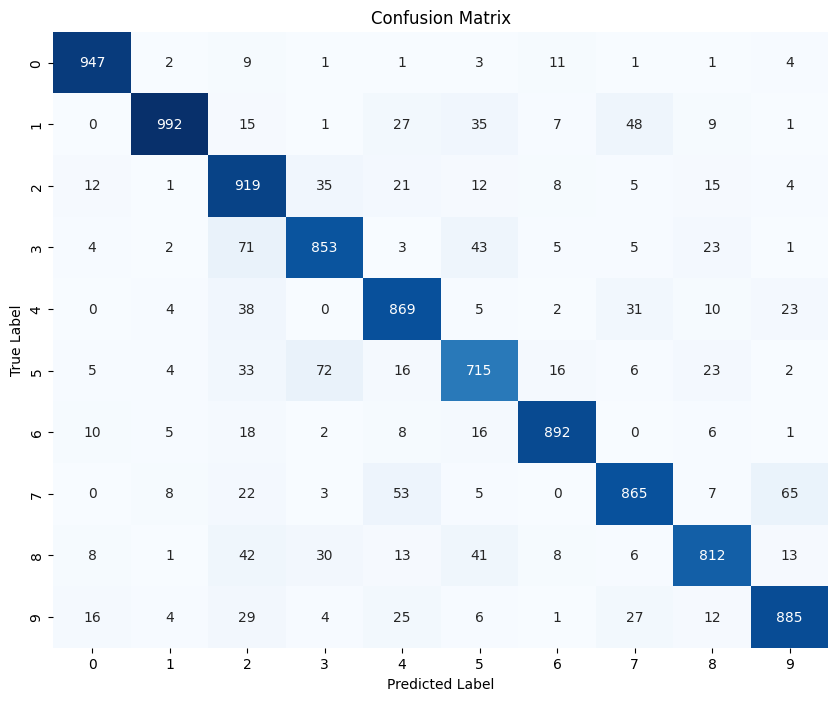

In [464]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)
cm = confusion_matrix(test_true_classes, test_predictions_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

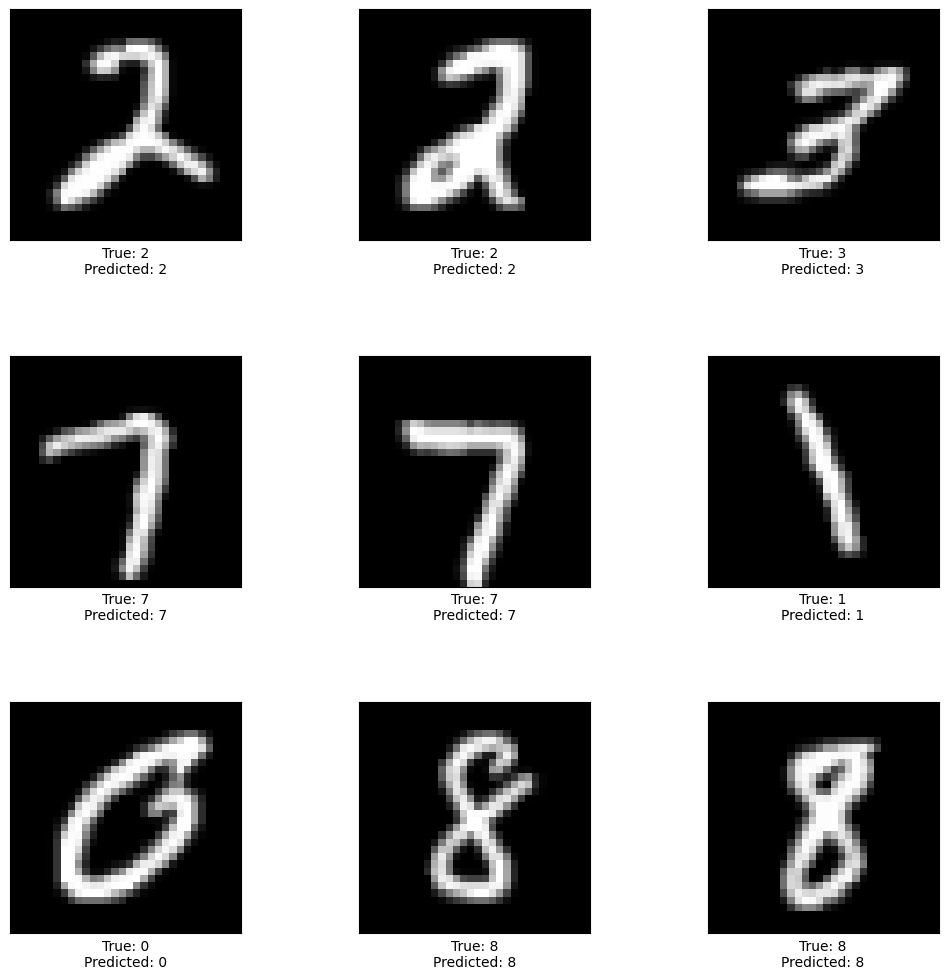

In [465]:
import matplotlib.pyplot as plt

def display_sample(sample_images, sample_labels, sample_predictions):
  fig, axes = plt.subplots(3, 3, figsize=(12, 12))
  fig.subplots_adjust(hspace=0.5, wspace=0.5)
  for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
    ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
    ax.set_xticks([])
    ax.set_yticks([])
  
  plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])
random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)